C:\Users\eljam\AppData\Local\Temp\ipykernel_29932\1696536656.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


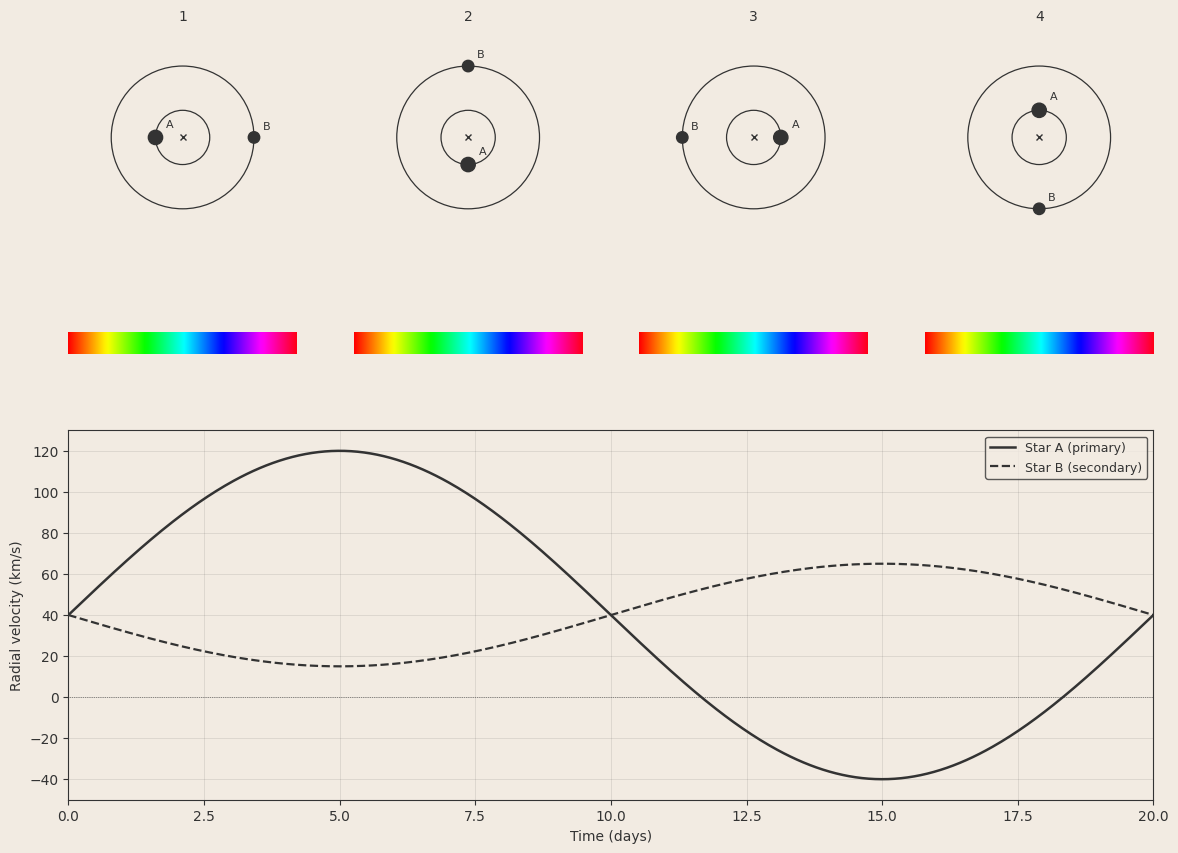

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

C = "#333333"
t = np.linspace(0, 20, 500)
P, v_sys, K_A, K_B = 20, 40, 80, 25
v_A = v_sys + K_A * np.sin(2 * np.pi * t / P)
v_B = v_sys - K_B * np.sin(2 * np.pi * t / P)

# Doppler spectrum: red -> white -> blue
dop_cmap = plt.cm.hsv
spec_img = np.linspace(0, 1, 256).reshape(1, -1)

fig = plt.figure(figsize=(14, 11), facecolor="#F2EBE2")
gs  = gridspec.GridSpec(4, 4, figure=fig,
                        height_ratios=[3, 0.18, 0.45, 3],
                        hspace=0.05, wspace=0.25)

# ── Orbit panels ──────────────────────────────────────────────
orbit_configs = [
    dict(label="1", A_xy=(-0.38, 0),  B_xy=(1.0, 0),   A_dv=(0,1),  B_dv=(0,1)),
    dict(label="2", A_xy=(0, -0.38),   B_xy=(0,1.0),   A_dv=(0,1),  B_dv=(0,-1)),
    dict(label="3", A_xy=(0.38, 0),   B_xy=(-1.0, 0),  A_dv=(0,-1), B_dv=(0,-1)),
    dict(label="4", A_xy=(0,0.38),   B_xy=(0, -1.0),   A_dv=(1,0),  B_dv=(1,0)),
]
for i, cfg in enumerate(orbit_configs):
    ax = fig.add_subplot(gs[0, i])
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.add_patch(Circle((0,0), 1.0, fill=False, ec=C, lw=0.9))
    ax.add_patch(Circle((0,0), 0.38, fill=False, ec=C, lw=0.9))
    ax.plot(0, 0, "x", color=C, ms=5, mew=1)
    # Stars at correct orbit radii
    ax.add_patch(Circle(cfg["A_xy"], 0.10, color=C))
    ax.add_patch(Circle(cfg["B_xy"], 0.08, color=C))
    ax.text(cfg["A_xy"][0]+0.15, cfg["A_xy"][1]+0.15, "A", fontsize=8, color=C)
    ax.text(cfg["B_xy"][0]+0.12, cfg["B_xy"][1]+0.12, "B", fontsize=8, color=C)
    ax.annotate("", xy=(cfg["A_xy"][0]+cfg["A_dv"][0]*0.38,
                        cfg["A_xy"][1]+cfg["A_dv"][1]*0.38),
                xytext=cfg["A_xy"])
    ax.annotate("", xy=(cfg["B_xy"][0]+cfg["B_dv"][0]*0.3,
                        cfg["B_xy"][1]+cfg["B_dv"][1]*0.3),
                xytext=cfg["B_xy"])
    ax.set_title(cfg["label"], fontsize=10, color=C, pad=1)


# ── Doppler colour bars (spectrum repeated ×4) ────────────────
for i in range(4):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(spec_img, aspect="auto", cmap=dop_cmap)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_facecolor("#F2EBE2")



# ── Radial velocity curve ──────────────────────────────────────
ax_rv = fig.add_subplot(gs[3, :])
ax_rv.set_facecolor("#F2EBE2")
ax_rv.plot(t, v_A, color=C, lw=1.8, ls="-",  label="Star A (primary)")
ax_rv.plot(t, v_B, color=C, lw=1.6, ls="--", label="Star B (secondary)")
ax_rv.axhline(0, color=C, lw=0.5, ls=":")
ax_rv.set_xlabel("Time (days)", color=C)
ax_rv.set_ylabel("Radial velocity (km/s)", color=C)
ax_rv.set_xlim(0, 20); ax_rv.set_ylim(-50, 130)
ax_rv.tick_params(colors=C)
for sp in ax_rv.spines.values(): sp.set_edgecolor(C)
ax_rv.legend(facecolor="#F2EBE2", edgecolor=C, labelcolor=C, fontsize=9)
ax_rv.grid(True, color=C, alpha=0.15, lw=0.5)

plt.tight_layout()
fig.savefig("Media/binary_star_diagram.svg", bbox_inches="tight")
plt.show()